<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/18_kNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-NN(k-Nearest Neighbors)로 TSLA 방향성 예측 (분류)
이 노트북은 다음 거래일의 **상승/하락(이진 분류)**을 예측합니다.
시계열에서는 **시간 순서 보존(train→test)**과 **정보누수 방지**가 핵심입니다.


## 🤖 알고리즘 상세 설명: k-NN (k-Nearest Neighbors)

k-NN은 **'유유상종'**의 원리를 이용한 직관적인 머신러닝 알고리즘입니다.

### 1. 작동 원리
새로운 데이터가 들어왔을 때, 기존의 학습 데이터 중 가장 거리가 가까운 **k개**의 이웃을 찾습니다. 그 후, 이웃들의 '다수결'에 따라 새로운 데이터의 카테고리를 결정합니다.

### 2. 핵심 수식 (유클리드 거리)
두 데이터 포인트 $A(x_1, y_1)$와 $B(x_2, y_2)$ 사이의 거리 $d$는 다음과 같이 계산됩니다:
$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - x_1)^2 + ...}$$

### 3. 주요 특징
- **스케일링 필수**: 거리를 기반으로 하므로, 단위가 큰 피처가 결과를 왜곡할 수 있어 반드시 데이터를 표준화(Scaling)해야 합니다.
- **하이퍼파라미터 k**: k가 너무 작으면 과적합(Overfitting), 너무 크면 과소적합(Underfitting)이 발생할 수 있습니다.

## 0) 환경 준비
```bash
pip install yfinance
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [2]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 247


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


### 🔍 피처(Feature) 상세 설명

모델의 예측 성능을 높이기 위해 사용된 7가지 기술적 지표의 의미는 다음과 같습니다.

1. **`ret_lag1` ~ `ret_lag10` (Lagged Returns)**:
    * **설명**: 각각 1일 전, 2일 전, 3일 전, 5일 전, 10일 전의 주가 수익률입니다.
    * **의도**: 과거의 수익률 패턴이 내일의 방향성에 영향을 주는지 학습합니다 (예: 어제 올랐으면 오늘도 오를까?).

2. **`ma_gap` (MA Cross Over Distance)**:
    * **계산**: `(5일 이동평균 / 20일 이동평균) - 1.0`
    * **설명**: 단기 평단가(5일)와 중기 평단가(20일) 사이의 이격도입니다.
    * **의도**: 단기 추세가 장기 추세 대비 얼마나 과열되었는지 또는 골든/데드크로스 근처에 있는지를 나타냅니다.

3. **`vol10` (Rolling Volatility)**:
    * **계산**: 최근 10일간 수익률의 표준편차(Standard Deviation)
    * **설명**: 최근 시장의 변동성(위험도)을 측정합니다.
    * **의도**: 시장이 불안정한 상태(고변동성)인지 안정적인 상태(저변동성)인지에 따라 상승 확률이 달라지는지 확인합니다.

In [3]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 228


## 3) 타깃/분할(시간 순서 보존)


In [4]:
# 타깃: 다음날 상승(1) / 하락(0)
df['ret_next'] = df['Close'].pct_change().shift(-1)
df['y_bin'] = (df['ret_next'] > 0).astype(int)
df = df.dropna().reset_index(drop=True)

features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']

# 시간 순서 보존 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (181, 7) Test: (46, 7)


## 4) 모델 학습


In [5]:
from sklearn.neighbors import KNeighborsClassifier

# 스케일링이 중요하므로 Pipeline 사용
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance'))
])
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=15, weights='distance'))])

## 5) 평가


[정확도] Accuracy: 0.4565
[AUC] ROC-AUC : 0.3939

--- 상세 분류 리포트 ---
              precision    recall  f1-score   support

       하락(0)     0.4000    0.2727    0.3243        22
       상승(1)     0.4839    0.6250    0.5455        24

    accuracy                         0.4565        46
   macro avg     0.4419    0.4489    0.4349        46
weighted avg     0.4438    0.4565    0.4397        46



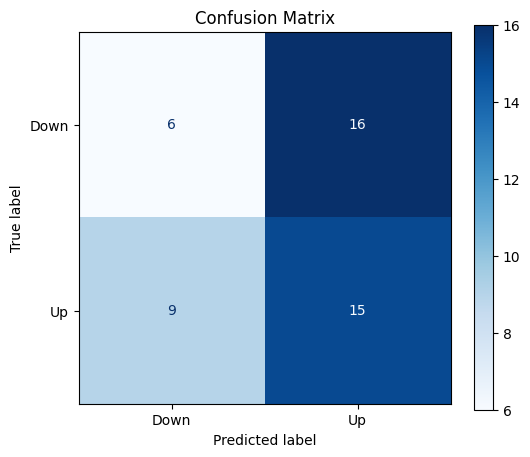


  [혼동 행렬 가이드]
- 왼쪽 위 (0,0): 실제 '하락'을 '하락'으로 정확히 맞춘 경우
- 오른쪽 아래 (1,1): 실제 '상승'을 '상승'으로 정확히 맞춘 경우
- 대각선 숫자가 높을수록 모델의 성능이 좋음을 의미합니다.


In [16]:
# 1. 테스트 데이터에 대한 예측 수행
y_pred = model.predict(X_test)

# 2. 확률 기반 평가가 가능한 경우 AUC 계산 (모델의 변별력 측정 지표)
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
else:
    y_proba, auc = None, None

# 3. 기본 성능 지표 출력
acc = accuracy_score(y_test, y_pred)
print(f"[정확도] Accuracy: {acc:.4f}")
if auc is not None:
    print(f"[AUC] ROC-AUC : {auc:.4f}")

# 4. 상세 분류 리포트 출력
print("\n--- 상세 분류 리포트 ---")
print(classification_report(y_test, y_pred, digits=4, target_names=['하락(0)', '상승(1)']))

# 5. 혼동 행렬 시각화 (그래프는 영어 유지)
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
display_cm.plot(values_format="d", cmap='Blues', ax=ax)
plt.title("Confusion Matrix")
plt.show()

print("\n  [혼동 행렬 가이드]")
print("- 왼쪽 위 (0,0): 실제 '하락'을 '하락'으로 정확히 맞춘 경우")
print("- 오른쪽 아래 (1,1): 실제 '상승'을 '상승'으로 정확히 맞춘 경우")
print("- 대각선 숫자가 높을수록 모델의 성능이 좋음을 의미합니다.")

## 6) 방향 요약 + 다음 거래일 예측


In [7]:
import numpy as np
import pandas as pd

prediction_counts = np.bincount(y_pred)
print(f"Predicted Down (하락): {prediction_counts[0] if len(prediction_counts) > 0 else 0} 건")
print(f"Predicted Up (상승): {prediction_counts[1] if len(prediction_counts) > 1 else 0} 건")

last_day_features = X.iloc[-1].values.reshape(1, -1)
next_day_prediction = model.predict(last_day_features)
prediction_label = "상승 (Up)" if int(next_day_prediction[0]) == 1 else "하락 (Down)"

last_date_in_df = df['Date'].iloc[-1]
predicted_date = last_date_in_df + pd.Timedelta(days=1)

print(f"다음 거래일 예측 (날짜: {predicted_date.strftime('%Y-%m-%d')}): {prediction_label}")


Predicted Down (하락): 15 건
Predicted Up (상승): 31 건
다음 거래일 예측 (날짜: 2026-03-24): 상승 (Up)


## ✅ 마지막 시각화(결과를 눈으로 확인)
마지막 셀은 반드시 그래프가 출력되도록 구성했습니다.


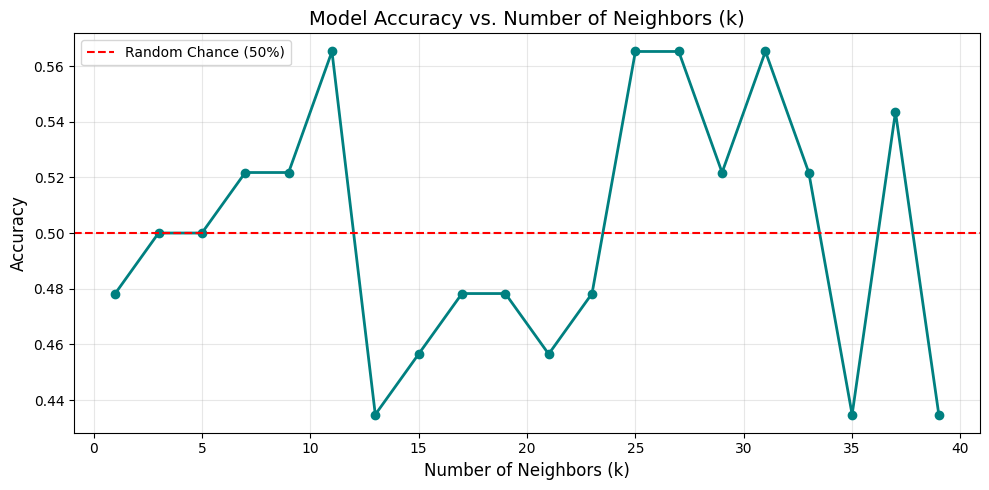


  [그래프 해석]
1. 최적의 k: 정확도가 가장 높은 지점의 k값을 선택하세요.
2. 기준선: 점들이 빨간 점선(0.5) 근처라면 모델의 예측력이 낮음을 의미합니다.
3. 안정성: 정확도가 급격히 변하지 않고 일정 구간 유지되는 k값이 신뢰도가 높습니다.


In [17]:
# 최적의 이웃 수(k)를 찾기 위한 반복 실험
ks = list(range(1, 41, 2))  # 1부터 40까지 홀수 단위 탐색
accs = []

for k in ks:
    # 파이프라인을 사용하여 각 반복마다 스케일링 적용
    temp_model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='distance'))
    ])
    temp_model.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, temp_model.predict(X_test)))

# 시각화 (그래프 레이블은 영어 유지)
plt.figure(figsize=(10, 5))
plt.plot(ks, accs, marker='o', linestyle='-', color='teal', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Random Chance (50%)')
plt.title('Model Accuracy vs. Number of Neighbors (k)', fontsize=14)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n  [그래프 해석]")
print("1. 최적의 k: 정확도가 가장 높은 지점의 k값을 선택하세요.")
print("2. 기준선: 점들이 빨간 점선(0.5) 근처라면 모델의 예측력이 낮음을 의미합니다.")
print("3. 안정성: 정확도가 급격히 변하지 않고 일정 구간 유지되는 k값이 신뢰도가 높습니다.")

## ✅ 요약(3줄)
1) 분류는 ‘가격’을 맞추는 것이 아니라 ‘방향(Up/Down)’을 예측합니다.
2) 시계열에서는 **시간 분할**과 **누수 방지**가 성능보다 먼저입니다.
3) 정확도만 보지 말고 AUC/혼동행렬/기준선과 함께 해석하세요.
